<a href="https://colab.research.google.com/github/Goutham-26/DSA/blob/main/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import os
import time
from datetime import datetime
import numpy as np
import pandas as pd

In [93]:
satellite_data=pd.read_excel('/content/satellite_data.xlsx')

OUT_DIR="Outputs"
INTERVAL_SECONDS =20
MAX_RUNS = 3

In [94]:
summary = pd.DataFrame({
    'Total Rows': len(satellite_data),
    'Null Rows': satellite_data.isnull().sum(),
    'Filled Rows': satellite_data.notnull().sum()
})
summary

,Total Rows,Null Rows,Filled Rows
"Name of Satellite, Alternate Names",7560,0,7560
Current Official Name of Satellite,7560,0,7560
Country/Org of UN Registry,7560,1,7559
Country of Operator/Owner,7560,0,7560
Operator/Owner,7560,0,7560
...,...,...,...
Unnamed: 63,7560,7075,485
Unnamed: 64,7560,7075,485
Unnamed: 65,7560,7075,485
Unnamed: 66,7560,7073,487


In [95]:
data

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAt-4,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"ABS-2 (Koreasat-8, ST-3)",ABS-2,NR,Multinational,Asia Broadcast Satellite Ltd.,Commercial,Communications,NaN,GEO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7555,Ziyuan 1-02C,Ziyuan 1-02C,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7556,Ziyuan 1-2D,Ziyuan 1-2D,NR,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Hyperspectral Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7557,Ziyuan 3 (ZY-3),Ziyuan 3,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7558,Ziyuan 3-2,Ziyuan 3-2,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
pd.DataFrame(data)

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAt-4,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"ABS-2 (Koreasat-8, ST-3)",ABS-2,NR,Multinational,Asia Broadcast Satellite Ltd.,Commercial,Communications,NaN,GEO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7555,Ziyuan 1-02C,Ziyuan 1-02C,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7556,Ziyuan 1-2D,Ziyuan 1-2D,NR,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Hyperspectral Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7557,Ziyuan 3 (ZY-3),Ziyuan 3,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7558,Ziyuan 3-2,Ziyuan 3-2,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
def extract():
    satellite_data_len = len(satellite_data)
    print(f"Extracted {satellite_data_len} rows")
    return satellite_data

def transform():

  processed_data = satellite_data.drop_duplicates()


  processed_data = processed_data.loc[:, ~processed_data.columns.duplicated()]

  processed_data['Date of Launch'] = pd.to_datetime(processed_data['Date of Launch'], errors='coerce')
  processed_data['Date of Launch'] = processed_data['Date of Launch'].dt.year.astype('Int64')


  cols_to_drop = [col for col in processed_data.columns if "Unnamed"  in col or "Source" in col]
  if cols_to_drop:
    processed_data = processed_data.drop(columns=cols_to_drop)

  return processed_data

def load(processed_data):
    if not os.path.exists(OUT_DIR):
        os.makedirs(OUT_DIR)

    output_file_path = f"{OUT_DIR}/satellite_data.csv"
    processed_data.to_csv(output_file_path, index=False)
    print(f"\n[LOAD SUCCESS] Saved transformed data to: {output_file_path}")

In [98]:
raw_data = extract()
processed_data = transform()
load(processed_data)

Extracted 7560 rows

[LOAD SUCCESS] Saved transformed data to: Outputs/satellite_data.csv


In [99]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7553 entries, 0 to 7559
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Name of Satellite, Alternate Names  7553 non-null   object 
 1   Current Official Name of Satellite  7553 non-null   object 
 2   Country/Org of UN Registry          7552 non-null   object 
 3   Country of Operator/Owner           7553 non-null   object 
 4   Operator/Owner                      7553 non-null   object 
 5   Users                               7553 non-null   object 
 6   Purpose                             7553 non-null   object 
 7   Detailed Purpose                    1254 non-null   object 
 8   Class of Orbit                      7553 non-null   object 
 9   Type of Orbit                       6902 non-null   object 
 10  Longitude of GEO (degrees)          7550 non-null   float64
 11  Perigee (km)                        7546 non-nul

In [100]:
processed_data

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Power (watts),Date of Launch,Expected Lifetime (yrs.),Contractor,Country of Contractor,Launch Site,Launch Vehicle,COSPAR Number,NORAD Number,Comments
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,NaN,2019,0.5,Hera Systems,USA,Satish Dhawan Space Centre,PSLV,2019-089H,44859,Pathfinder for planned earth observation const...
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,2023,NaN,AAC Clyde Space,Sweden/UK/USA/Netherlands,Cape Canaveral,Falcon 9,2023-001DC,55107,Provide AIS information to Orbcomm.
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,4.5,2017,2.0,Aalto University,Finland,Satish Dhawan Space Centre,PSLV,2017-036L,42775,Technology development and education.
3,AAt-4,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,2016,NaN,University of Aalborg,Denmark,Guiana Space Center,Soyuz-2.1a,2016-025E,41460,Carries AIS system.
4,"ABS-2 (Koreasat-8, ST-3)",ABS-2,NR,Multinational,Asia Broadcast Satellite Ltd.,Commercial,Communications,NaN,GEO,NaN,...,16000,2014,15.0,Space Systems/Loral,USA,Guiana Space Center,Ariane 5 ECA,2014-006A,39508,"32 C-band, 51 Ku-band, and 6 Ka-band transpond..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7555,Ziyuan 1-02C,Ziyuan 1-02C,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,2011,NaN,China Academy of Space Technology (CAST),China,Taiyuan Launch Center,Long March 4B,2011-079A,38038,Can acquire high-resolution data through remot...
7556,Ziyuan 1-2D,Ziyuan 1-2D,NR,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Hyperspectral Imaging,LEO,Sun-Synchronous,...,NaN,2019,5.0,China Academy of Space Technology (CAST),China,Taiyuan Launch Center,Long March 4B,2019-059A,44528,Hyperspectral imaging
7557,Ziyuan 3 (ZY-3),Ziyuan 3,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,2012,4.0,China Academy of Space Technology (CAST),China,Taiyuan Launch Center,Long March 4B,2012-001A,38046,Land survey satellite.
7558,Ziyuan 3-2,Ziyuan 3-2,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,NaN,2016,4.0,China Academy of Space Technology (CAST),China,Taiyuan Launch Center,Long March 4B,2016-033A,41556,Thought to be for intelligence gathering.


<Axes: >

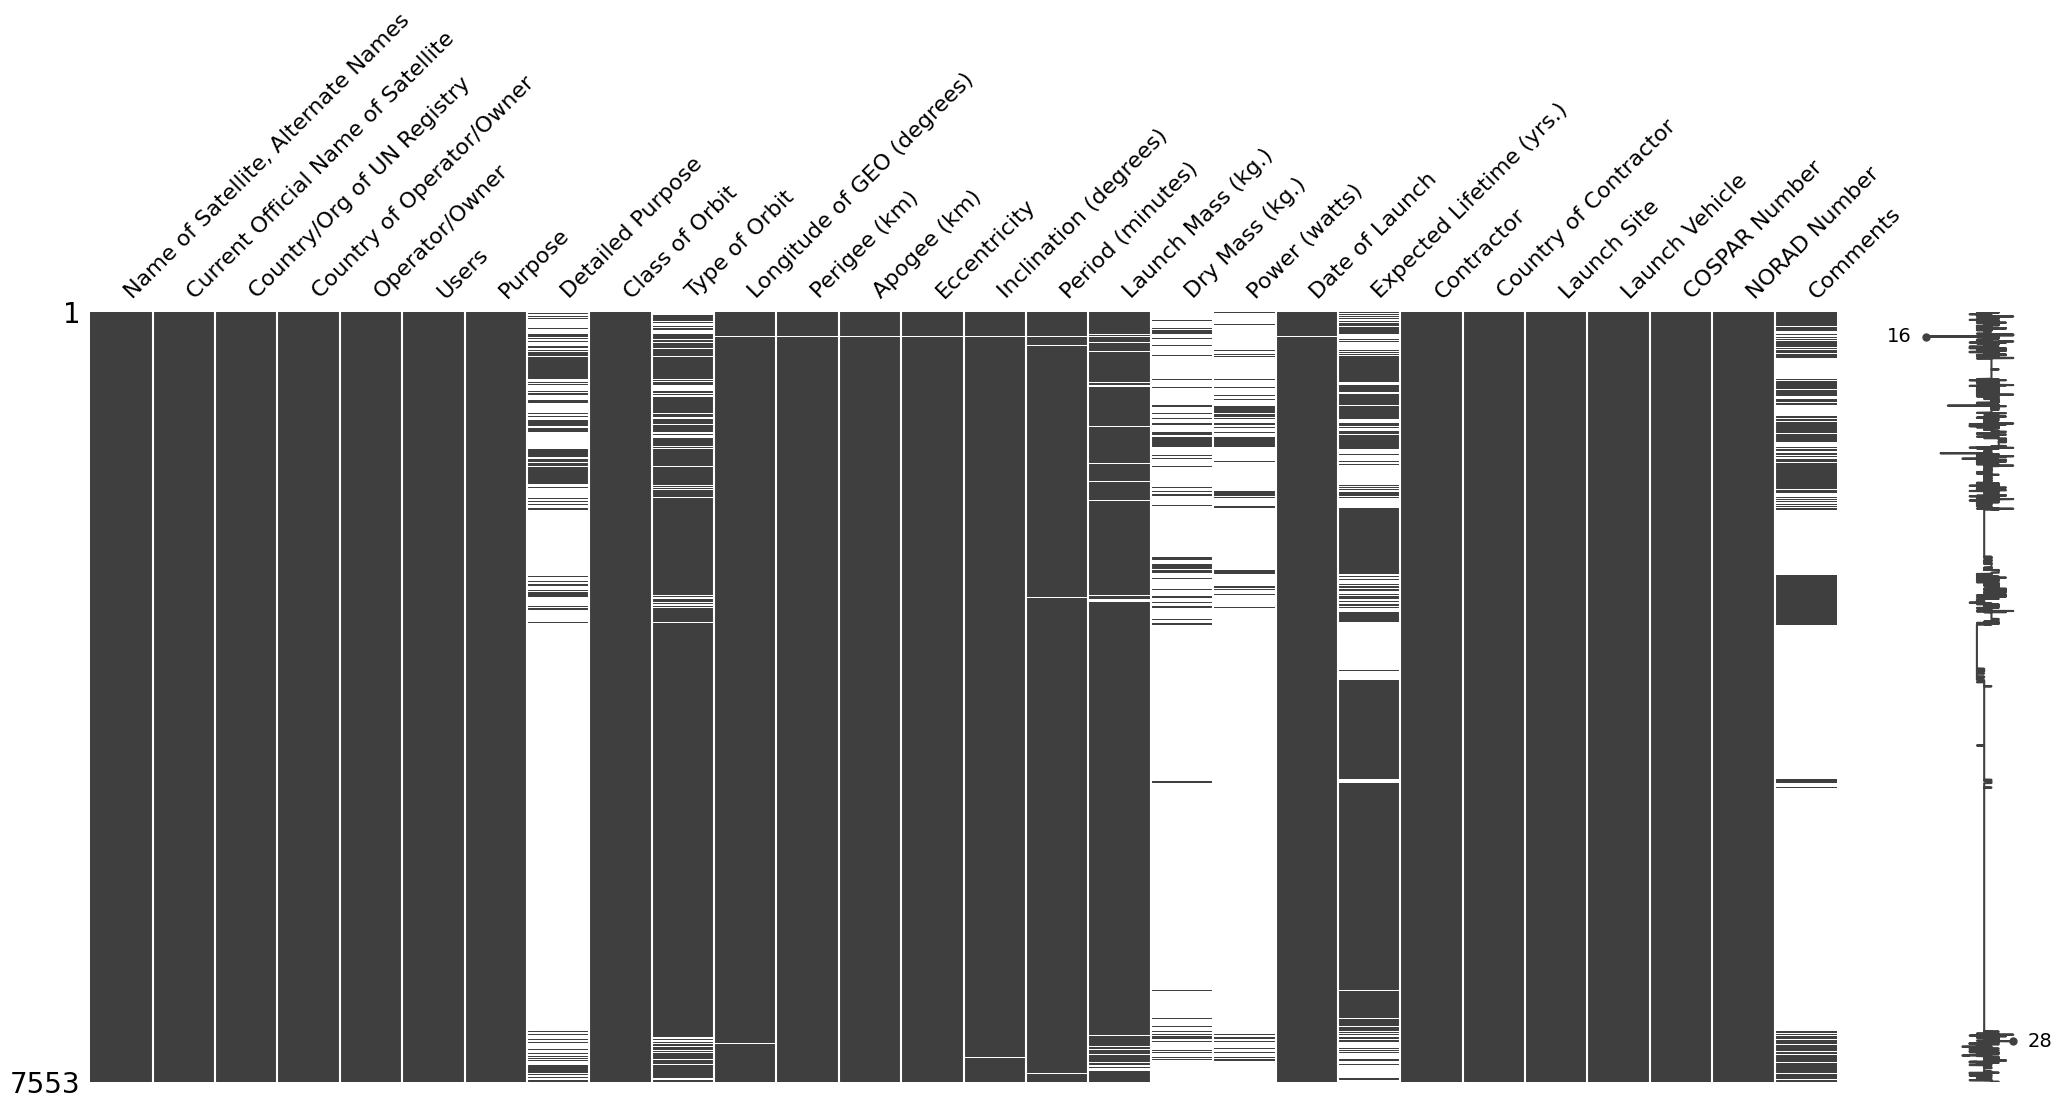

In [101]:
import missingno as msn
msn.matrix(processed_data)

In [102]:
processed_data.columns

Index(['Name of Satellite, Alternate Names',
       'Current Official Name of Satellite', 'Country/Org of UN Registry',
       'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose',
       'Detailed Purpose', 'Class of Orbit', 'Type of Orbit',
       'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)',
       'Eccentricity', 'Inclination (degrees)', 'Period (minutes)',
       'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)',
       'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor',
       'Country of Contractor', 'Launch Site', 'Launch Vehicle',
       'COSPAR Number', 'NORAD Number', 'Comments'],
      dtype='object')

In [103]:
processed_data.drop(['Dry Mass (kg.)','Power (watts)','Comments','Detailed Purpose'], axis=1, inplace=True)
processed_data.isnull().sum()

,0
"Name of Satellite, Alternate Names",0
Current Official Name of Satellite,0
Country/Org of UN Registry,1
Country of Operator/Owner,0
Operator/Owner,0
Users,0
Purpose,0
Class of Orbit,0
Type of Orbit,651
Longitude of GEO (degrees),3


In [104]:
processed_data['Date of Launch'] = processed_data['Date of Launch'].fillna(processed_data['Date of Launch'].median())

In [105]:
for col in processed_data.columns:
  if processed_data[col].isnull().any():
    if processed_data[col].dtype in ['float64','int64']:
      processed_data[col]=processed_data[col].fillna(processed_data[col].median())
      print("Median is applied to the numbers")
    elif processed_data[col].dtype=='object':
      processed_data[col]=processed_data[col].fillna(processed_data[col].mode()[0])
      print("Mode is applied to the objects")

processed_data.isnull().sum()

Mode is applied to the objects
Mode is applied to the objects
Median is applied to the numbers
Median is applied to the numbers
Median is applied to the numbers
Median is applied to the numbers
Median is applied to the numbers
Median is applied to the numbers
Median is applied to the numbers
Median is applied to the numbers


,0
"Name of Satellite, Alternate Names",0
Current Official Name of Satellite,0
Country/Org of UN Registry,0
Country of Operator/Owner,0
Operator/Owner,0
Users,0
Purpose,0
Class of Orbit,0
Type of Orbit,0
Longitude of GEO (degrees),0


<Axes: >

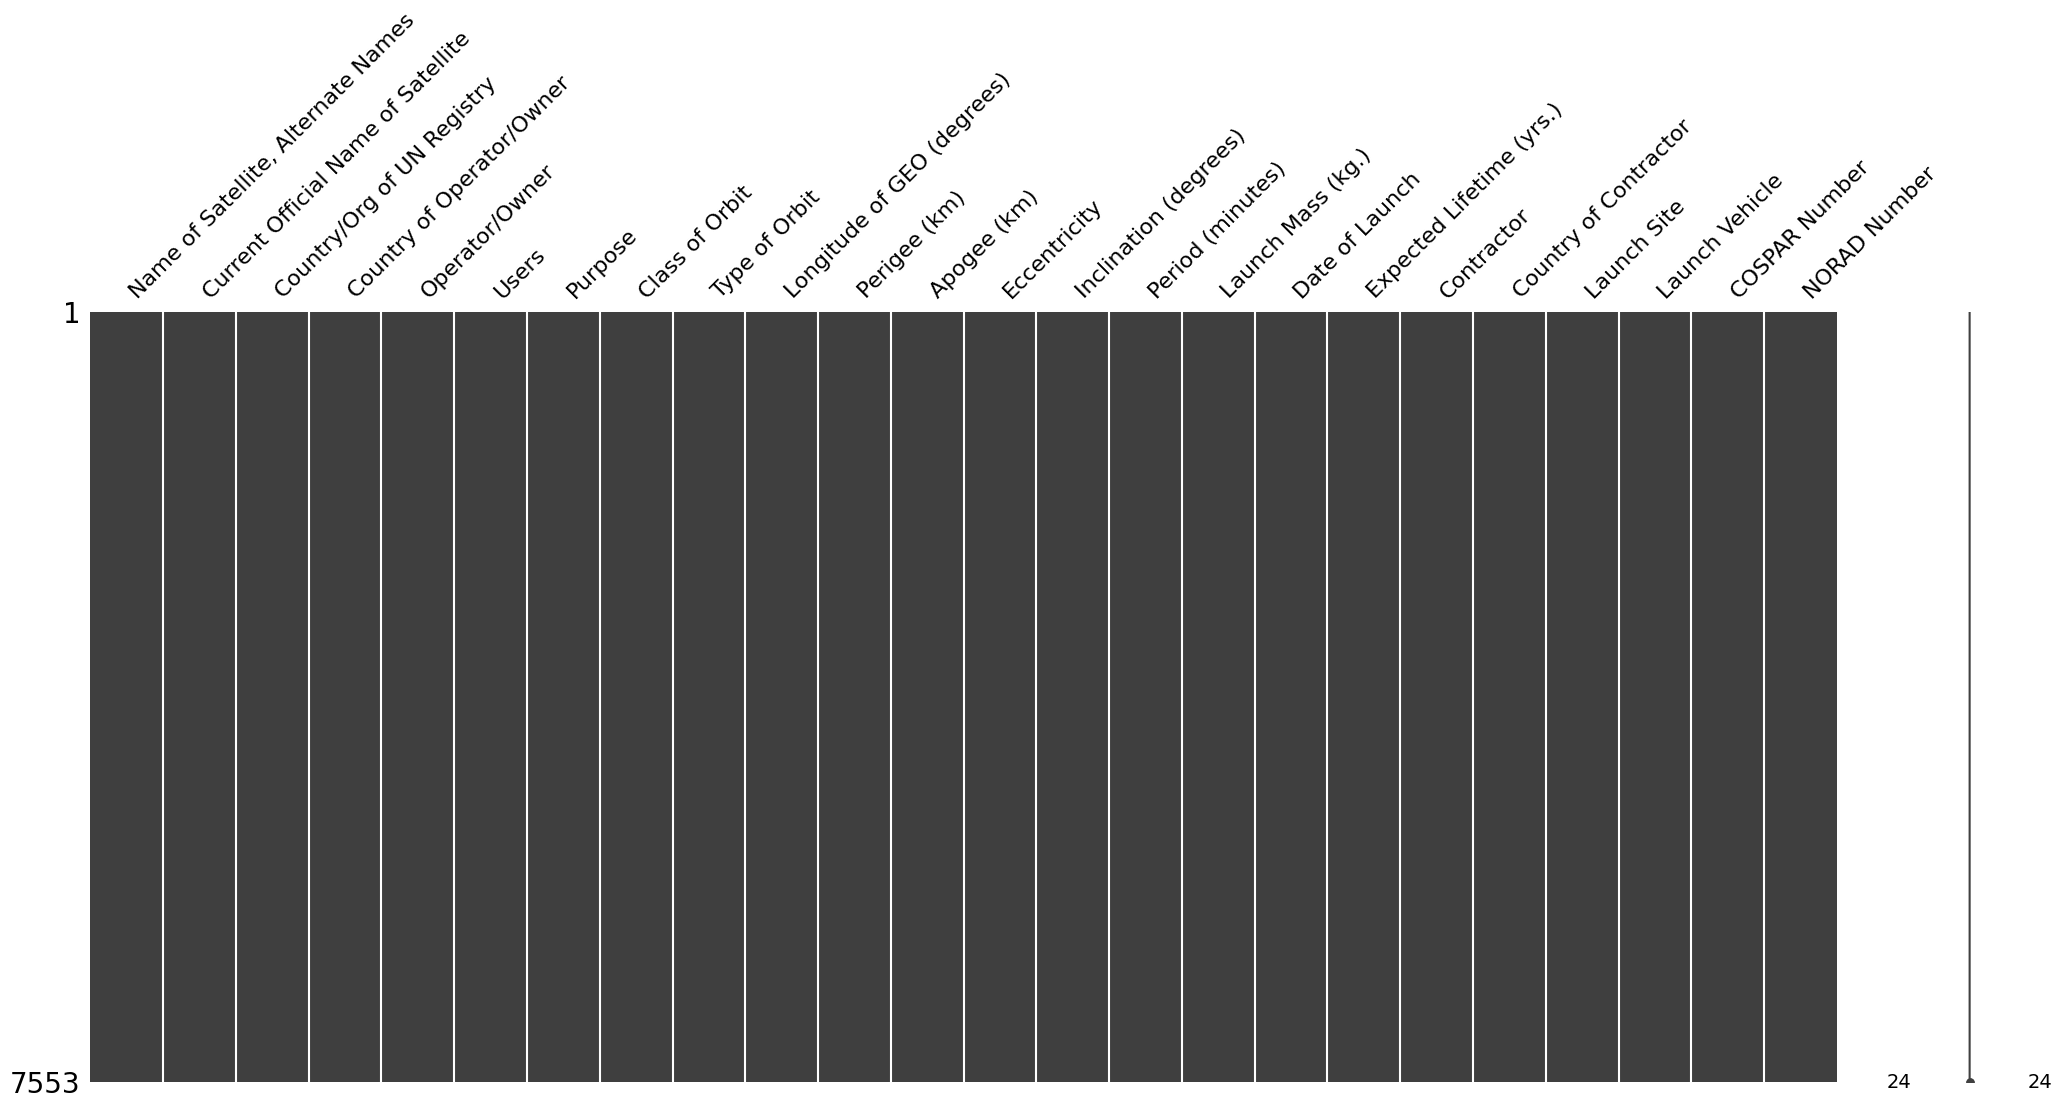

In [106]:
msn.matrix(processed_data)

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_670/780164320.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class of Orbit', data=processed_data, palette='Set2')
/tmp/ipykernel_670/780164320.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class of Orbit', y='Launch Mass (kg.)', data=processed_data, palette='Blues')


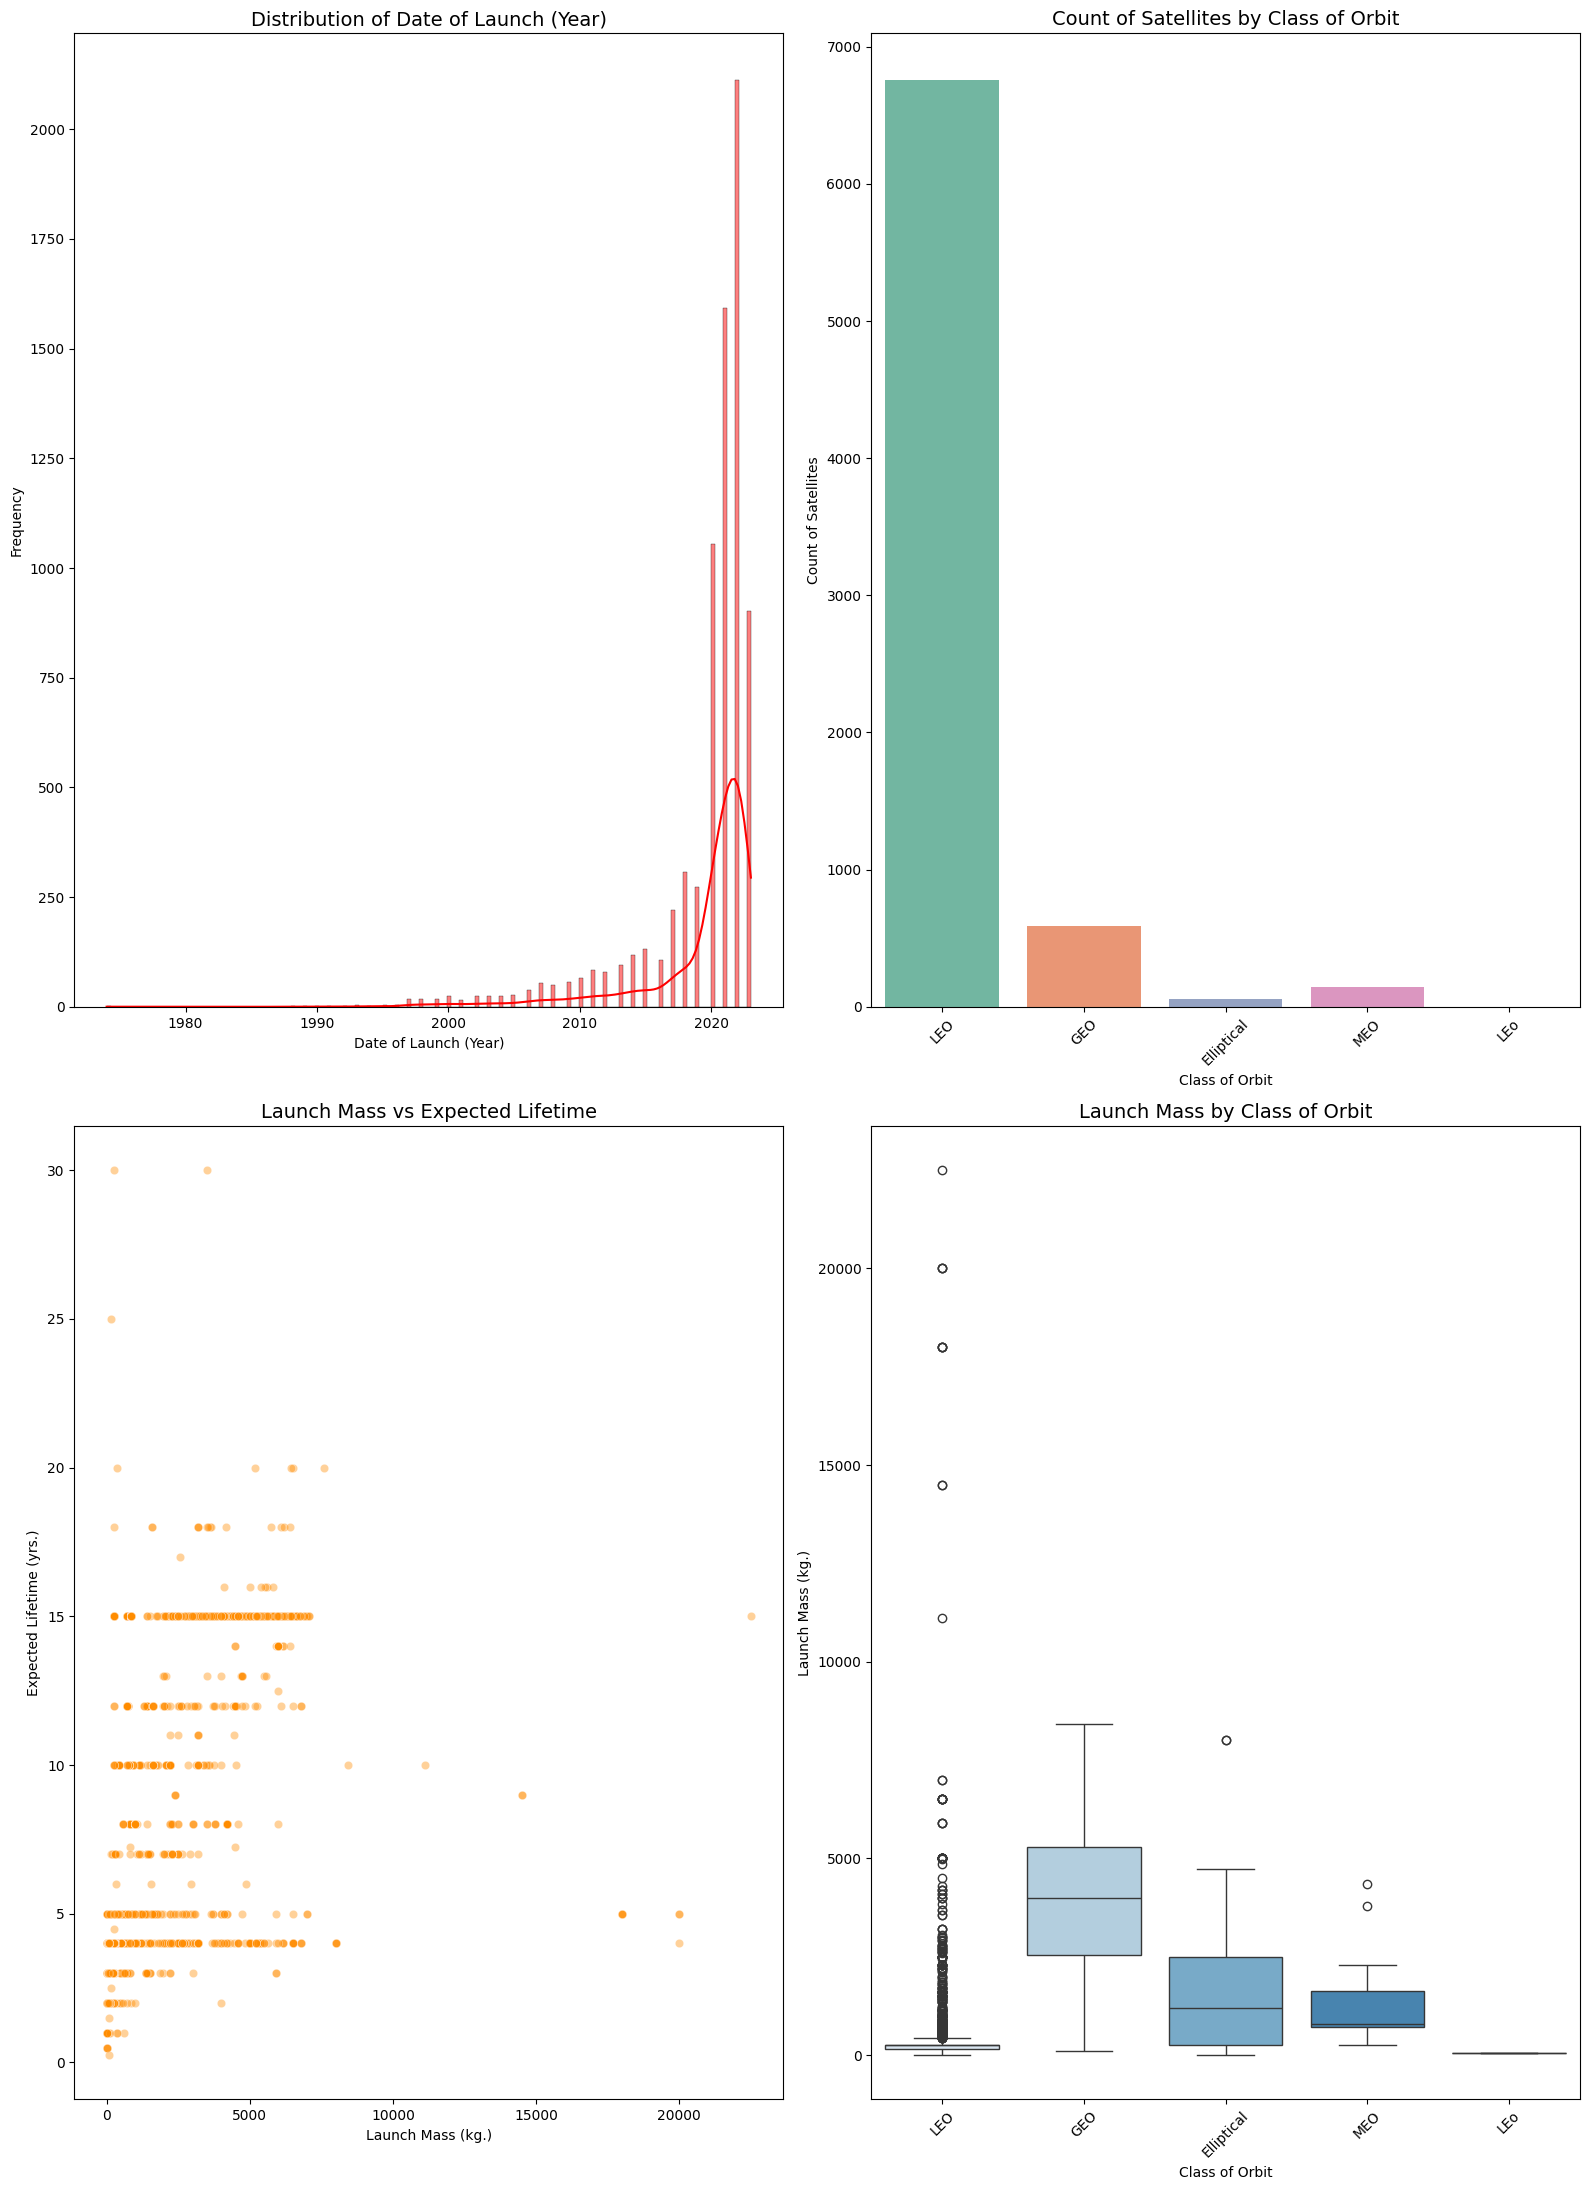

In [108]:
plt.figure(figsize=(16,22))
plt.subplot(2,2,1)
sns.histplot(processed_data['Date of Launch'],kde=True,color='red')
plt.title('Distribution of Date of Launch (Year)', fontsize=14)
plt.xlabel('Date of Launch (Year)')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.countplot(x='Class of Orbit', data=processed_data, palette='Set2')
plt.title('Count of Satellites by Class of Orbit', fontsize=14)
plt.xlabel('Class of Orbit')
plt.ylabel('Count of Satellites')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.scatterplot(x='Launch Mass (kg.)', y='Expected Lifetime (yrs.)', data=processed_data, alpha=0.4, color='darkorange')
plt.title('Launch Mass vs Expected Lifetime', fontsize=14)
plt.xlabel('Launch Mass (kg.)')
plt.ylabel('Expected Lifetime (yrs.)')


plt.subplot(2, 2, 4)
sns.boxplot(x='Class of Orbit', y='Launch Mass (kg.)', data=processed_data, palette='Blues')
plt.title('Launch Mass by Class of Orbit', fontsize=14)
plt.xlabel('Class of Orbit')
plt.ylabel('Launch Mass (kg.)')
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

In [109]:
import numpy as np
import pandas as pd

outlier_col = 'Launch Mass (kg.)'

processed_data_cleaned = processed_data.copy()

print(f"Shape before outlier removal: {processed_data_cleaned.shape}")

cleaned_groups = []
for orbit_class, group in processed_data_cleaned.groupby('Class of Orbit'):
    Q1 = group[outlier_col].quantile(0.25)
    Q3 = group[outlier_col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    filtered_group = group[(group[outlier_col] >= lower_bound) & (group[outlier_col] <= upper_bound)]
    cleaned_groups.append(filtered_group)

satellite_cleaned = pd.concat(cleaned_groups, axis=0)

print(f"Shape after outlier removal: {satellite_cleaned.shape}")

Shape before outlier removal: (7553, 24)
Shape after outlier removal: (7102, 24)


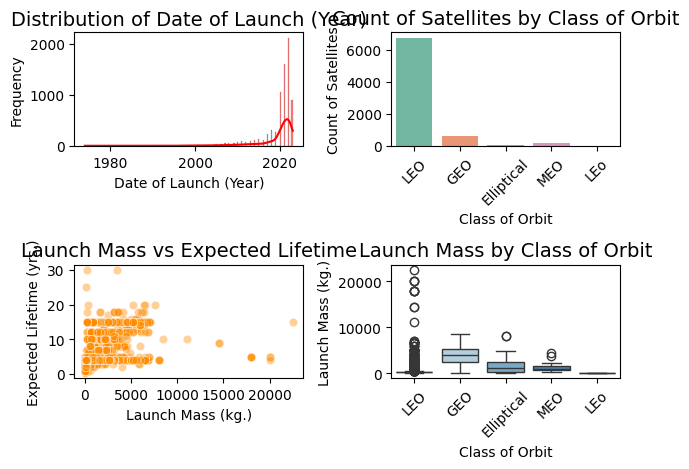

In [110]:

plt.subplot(2,2,1)
sns.histplot(processed_data['Date of Launch'], kde=True, color='red')
plt.title('Distribution of Date of Launch (Year)', fontsize=14)
plt.xlabel('Date of Launch (Year)')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.countplot(x='Class of Orbit', hue='Class of Orbit', data=processed_data, palette='Set2', legend=False)
plt.title('Count of Satellites by Class of Orbit', fontsize=14)
plt.xlabel('Class of Orbit')
plt.ylabel('Count of Satellites')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.scatterplot(x='Launch Mass (kg.)', y='Expected Lifetime (yrs.)', data=processed_data, alpha=0.4, color='darkorange')
plt.title('Launch Mass vs Expected Lifetime', fontsize=14)
plt.xlabel('Launch Mass (kg.)')
plt.ylabel('Expected Lifetime (yrs.)')


plt.subplot(2, 2, 4)
sns.boxplot(x='Class of Orbit', y='Launch Mass (kg.)', hue='Class of Orbit', data=processed_data, palette='Blues', legend=False)
plt.title('Launch Mass by Class of Orbit', fontsize=14)
plt.xlabel('Class of Orbit')
plt.ylabel('Launch Mass (kg.)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [111]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [112]:
label_encoder = LabelEncoder()
satellite_cleaned['Name of Satellite, Alternate Names'] = label_encoder.fit_transform(satellite_cleaned['Name of Satellite, Alternate Names'])

print("--- After Encoding ---")

print(satellite_cleaned[['Name of Satellite, Alternate Names']])

--- After Encoding ---
      Name of Satellite, Alternate Names
104                                  106
319                                  332
691                                  625
692                                  626
693                                  627
...                                  ...
1923                                1595
1924                                1596
1925                                1597
1926                                1598
7287                                6809

[7102 rows x 1 columns]


In [113]:
satellite_cleaned

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Class of Orbit,Type of Orbit,Longitude of GEO (degrees),...,Period (minutes),Launch Mass (kg.),Date of Launch,Expected Lifetime (yrs.),Contractor,Country of Contractor,Launch Site,Launch Vehicle,COSPAR Number,NORAD Number
104,106,Arktika-M1,Russia,Russia,Naval Physical and Oceanographic Laboratory,Government,Earth Observation,Elliptical,Non-Polar Inclined,0.0,...,717.80,2200.0,2021,7.0,NPO Lavochkin,Russia,Baikonur Cosmodrome,Soyuz-2.1b,2021-016A,47719
319,332,Chandra X-Ray Observatory (CXO),USA,USA,National Aeronautics and Space Administration ...,Government,Space Science,Elliptical,Deep Highly Eccentric,0.0,...,3808.92,4742.0,1999,5.0,TRW Space and Electronics,USA,Cape Canaveral,Space Shuttle (STS 93),1999-040B,25867
691,625,Cosmos 2510,Russia,Russia,Ministry of Defense,Military,Earth Observation,Elliptical,Molniya,0.0,...,715.00,260.0,2015,4.0,RKK Energia,Russia,Plesetsk Cosmodrome,Soyuz-2.1,2015-066A,41032
692,626,Cosmos 2518,Russia,Russia,Ministry of Defense,Military,Earth Observation,Elliptical,Molniya,0.0,...,713.80,260.0,2017,4.0,RKK Energia,Russia,Plesetsk Cosmodrome,Soyuz-2.1b,2017-027A,42719
693,627,Cosmos 2541,Russia,Russia,Ministry of Defense,Military,Earth Observation,Elliptical,Molniya,0.0,...,717.70,260.0,2019,4.0,RKK Energia,Russia,Plesetsk Cosmodrome,Soyuz-2.1b,2019-065A,44552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,1595,O3b FM18,United Kingdom,United Kingdom,O3b Networks Ltd.,Commercial,Communications,MEO,Equatorial,0.0,...,281.02,700.0,2019,4.0,Thales Alenia Space,France,Guiana Space Center,Soyuz-ST-B,2019-020D,44115
1924,1596,O3b FM19,United Kingdom,United Kingdom,O3b Networks Ltd.,Commercial,Communications,MEO,Equatorial,0.0,...,280.86,700.0,2019,4.0,Thales Alenia Space,France,Guiana Space Center,Soyuz-ST-B,2019-020B,44113
1925,1597,O3b FM20,United Kingdom,United Kingdom,O3b Networks Ltd.,Commercial,Communications,MEO,Equatorial,0.0,...,280.73,700.0,2019,4.0,Thales Alenia Space,France,Guiana Space Center,Soyuz-ST-B,2019-020A,44112
1926,1598,O3b PFM,United Kingdom,United Kingdom,O3b Networks Ltd.,Commercial,Communications,MEO,Equatorial,0.0,...,287.93,700.0,2013,4.0,Thales Alenia Space,France,Guiana Space Center,Soyuz-ST,2013-031D,39191


In [114]:
numerical_cols = satellite_cleaned.select_dtypes(include=['object']).columns.tolist()
print("numerical_cols:",numerical_cols)

features_to_scale = [col for col in numerical_cols]

for col in features_to_scale:
    satellite_cleaned[col] = satellite_cleaned[col].astype(str)
    satellite_cleaned[col] = label_encoder.fit_transform(satellite_cleaned[col])

satellite_cleaned

numerical_cols: ['Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Class of Orbit', 'Type of Orbit', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle', 'COSPAR Number']


,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Class of Orbit,Type of Orbit,Longitude of GEO (degrees),...,Period (minutes),Launch Mass (kg.),Date of Launch,Expected Lifetime (yrs.),Contractor,Country of Contractor,Launch Site,Launch Vehicle,COSPAR Number,NORAD Number
104,106,105,54,62,373,9,4,0,5,0.0,...,717.80,2200.0,2021,7.0,284,63,1,121,2884,47719
319,332,320,61,79,349,9,22,0,1,0.0,...,3808.92,4742.0,1999,5.0,439,86,2,131,60,25867
691,625,394,54,62,317,15,4,0,4,0.0,...,715.00,260.0,2015,4.0,360,63,18,119,803,41032
692,626,398,54,62,317,15,4,0,4,0.0,...,713.80,260.0,2017,4.0,360,63,18,121,974,42719
693,627,414,54,62,317,15,4,0,4,0.0,...,717.70,260.0,2019,4.0,360,63,18,121,1453,44552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,1595,1526,64,87,389,4,0,4,3,0.0,...,281.02,700.0,2019,4.0,450,22,7,126,1363,44115
1924,1596,1527,64,87,389,4,0,4,3,0.0,...,280.86,700.0,2019,4.0,450,22,7,126,1361,44113
1925,1597,1528,64,87,389,4,0,4,3,0.0,...,280.73,700.0,2019,4.0,450,22,7,126,1360,44112
1926,1598,1529,64,87,389,4,0,4,3,0.0,...,287.93,700.0,2013,4.0,450,22,7,125,557,39191


In [115]:
satellite_cleaned['COSPAR Number'].value_counts()

,count
COSPAR Number,
6175,2
4664,1
4675,1
4671,1
4656,1
...,...
3642,1
1386,1
1028,1


In [116]:
from sklearn.model_selection import train_test_split

X = processed_data.drop(columns=['Name of Satellite, Alternate Names', 'Class of Orbit'])
y = processed_data['Class of Orbit']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Feature Rows (X): {X.shape[0]}, Columns: {X.shape[1]}")
print(f"Training Features (X_train): {X_train.shape[0]} rows")
print(f"Testing Features (X_test):   {X_test.shape[0]} rows")

Total Feature Rows (X): 7553, Columns: 22
Training Features (X_train): 6042 rows
Testing Features (X_test):   1511 rows
